In [4]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [5]:
model=ChatGroq(model="openai/gpt-oss-120b")

In [6]:
# MessagesState is a special state type that automatically includes a messages field. This field is a list of messages (like human or AI messages) and already includes a reducer that appends new messages as the state is updated.
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {
        "messages": [response]
        }

In [7]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

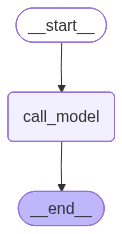

In [9]:
graph= builder.compile()
graph

In [10]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Bhavya."}]})

{'messages': [HumanMessage(content='Hi! My name is Bhavya.', additional_kwargs={}, response_metadata={}, id='070f5f95-5d0d-41cb-879b-20788f4f7601'),
  AIMessage(content='Hello, Bhavya! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'We need to greet Bhavya, maybe ask how can help. Follow policies.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 80, 'total_tokens': 127, 'completion_time': 0.101758057, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.003431743, 'prompt_tokens_details': None, 'queue_time': 0.054886517, 'total_time': 0.1051898}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e6570-e657-7781-ab78-2f95f45c9260-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 80, 'output_tokens': 47, 'total_tokens': 127, 'output_to

In [ ]:
# this is without the persistence inmemory saver
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})

{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='2ae8bf49-4846-42c4-ada0-f04e5462581e'),
  AIMessage(content='I don’t actually know your name—unless you’d like to tell me, I can’t guess it. If you’d like me to address you by a particular name, just let me know!', additional_kwargs={'reasoning_content': 'The user asks "What is my name?" There\'s no prior conversation with name. The user hasn\'t provided name. According to policy, we must not guess personal info. We can respond that we don\'t know their name. Ask if they\'d like to share.'}, response_metadata={'token_usage': {'completion_tokens': 100, 'prompt_tokens': 76, 'total_tokens': 176, 'completion_time': 0.209605139, 'completion_tokens_details': {'reasoning_tokens': 51}, 'prompt_time': 0.002907319, 'prompt_tokens_details': None, 'queue_time': 0.047674581, 'total_time': 0.212512458}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_